In [1]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

2026-07-04 07:40:15.875620: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-04 07:40:15.915166: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-04 07:40:20.362574: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.9.1


In [3]:
datasetPath = 'dataset/firstorder/kernel5-radius5/dataset.csv'

In [4]:
# Parameters
datasetPath = "dataset/firstorder/kernel5-radius5/500.dataset.csv"


In [5]:
# train/validation/test = 70/10/20
dataset = pd.read_csv(datasetPath)

train_data, temp_data = train_test_split(dataset, test_size=0.3, random_state=42)
validation_data, test_data = train_test_split(temp_data, test_size=2/3, random_state=42)

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# tinh class weight tren tap train
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label"])
class_weight = {0: weights[0], 1: weights[1]}

# gan sample_weight cho tung dong
train_data["sample_weight"] = train_data["label"].map(class_weight)
validation_data["sample_weight"] = validation_data["label"].map(class_weight)
test_data["sample_weight"] = test_data["label"].map(class_weight)

# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label", weight="sample_weight"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label", weight="sample_weight"
)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data, label="label", weight="sample_weight"
)

2026-07-04 07:40:34.531288: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-04 07:40:34.533192: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
import keras

In [8]:
%%time

# Train a Gradient Boosted Trees model.
model = tfdf.keras.GradientBoostedTreesModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmp6dhoa4pz as temporary training directory


[WARNING 26-07-04 07:40:34.7375 UTC gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 26-07-04 07:40:34.7375 UTC gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 26-07-04 07:40:34.7375 UTC gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Reading training dataset...


Training dataset read in 0:00:04.310101. Found 395895 examples.


Training model...


Model trained in 0:01:43.673404


Compiling model...


[INFO 26-07-04 07:42:22.7250 UTC kernel.cc:1233] Loading model from path /tmp/tmp6dhoa4pz/model/ with prefix 78b0a55554d641e5
[INFO 26-07-04 07:42:22.7420 UTC quick_scorer_extended.cc:911] The binary was compiled without AVX2 support, but your CPU supports it. Enable it for faster model inference.
[INFO 26-07-04 07:42:22.7433 UTC abstract_model.cc:1362] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 26-07-04 07:42:22.7434 UTC kernel.cc:1061] Use fast generic engine


Model compiled.


CPU times: user 13min 47s, sys: 5.18 s, total: 13min 52s
Wall time: 1min 51s


In [9]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

 1/57 [..............................] - ETA: 2:47 - loss: 0.0000e+00 - accuracy: 0.8680

10/57 [====>.........................] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.8667  

20/57 [=========>....................] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.8655

31/57 [===============>..............] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.8659

42/57 [=====================>........] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.8656

53/57 [==========================>...] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.8658

57/57 [==============================] - 3s 5ms/step - loss: 0.0000e+00 - accuracy: 0.8659



loss: 0.0000
accuracy: 0.8659


In [10]:
# Model Summary
model.summary()

Model: "gradient_boosted_trees_model"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


Total params: 1 (1.00 Byte)


Trainable params: 0 (0.00 Byte)


Non-trainable params: 1 (1.00 Byte)


_________________________________________________________________


Type: "GRADIENT_BOOSTED_TREES"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (18):
	10Percentile
	90Percentile
	Energy
	Entropy
	InterquartileRange
	Kurtosis
	Maximum
	Mean
	MeanAbsoluteDeviation
	Median
	Minimum
	Range
	RobustMeanAbsoluteDeviation
	RootMeanSquared
	Skewness
	TotalEnergy
	Uniformity
	Variance

Trained with weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.                    "Skewness"  0.224424 ################
    2.                       "Range"  0.212021 ############
    3.                     "Minimum"  0.210184 ###########
    4.                "90Percentile"  0.208448 ###########
    5.                    "Kurtosis"  0.207381 ##########
    6.                     "Maximum"  0.200333 ########
    7.                      "Median"  0.199225 ########
    8.                "10Percentile"  0.197632 #######
    9.                    "Variance"  0.191320 #####
   10.                  "Uniformity"  0.190588 #####
   11. "RobustMeanAbsoluteDeviation"  0.1839

In [11]:
# Model features
model.make_inspector().features()

["10Percentile" (1; #0),
 "90Percentile" (1; #1),
 "Energy" (1; #2),
 "Entropy" (1; #3),
 "InterquartileRange" (1; #4),
 "Kurtosis" (1; #5),
 "Maximum" (1; #6),
 "Mean" (1; #7),
 "MeanAbsoluteDeviation" (1; #8),
 "Median" (1; #9),
 "Minimum" (1; #10),
 "Range" (1; #11),
 "RobustMeanAbsoluteDeviation" (1; #12),
 "RootMeanSquared" (1; #13),
 "Skewness" (1; #14),
 "TotalEnergy" (1; #15),
 "Uniformity" (1; #16),
 "Variance" (1; #17)]

In [12]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("Skewness" (1; #14), 0.22442443970185316),
  ("Range" (1; #11), 0.21202148707465432),
  ("Minimum" (1; #10), 0.21018386974096467),
  ("90Percentile" (1; #1), 0.2084478431963311),
  ("Kurtosis" (1; #5), 0.20738114282005712),
  ("Maximum" (1; #6), 0.20033272124794732),
  ("Median" (1; #9), 0.19922465581581755),
  ("10Percentile" (1; #0), 0.19763195128085112),
  ("Variance" (1; #17), 0.19131962675232742),
  ("Uniformity" (1; #16), 0.19058809542839017),
  ("RobustMeanAbsoluteDeviation" (1; #12), 0.1839713841061216),
  ("Mean" (1; #7), 0.18234995819153857),
  ("Entropy" (1; #3), 0.18009573301538295),
  ("MeanAbsoluteDeviation" (1; #8), 0.17924946255436514),
  ("InterquartileRange" (1; #4), 0.17842914522631204),
  ("RootMeanSquared" (1; #13), 0.17465217904371214),
  ("Energy" (1; #2), 0.17346794530759957),
  ("TotalEnergy" (1; #15), 0.17236054390672506)],
 'NUM_AS_ROOT': [("Minimum" (1; #10), 42.0),
  ("Range" (1; #11), 42.0),
  ("Skewness" (1; #14), 41.0),
  ("Kurto

In [13]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=None, accuracy=0.8327990174293518, loss=0.7298069596290588, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

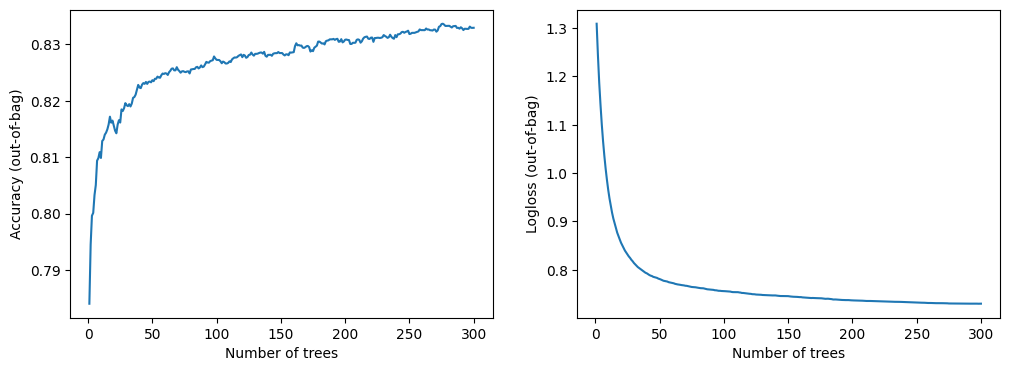

In [14]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [15]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

 1/57 [..............................] - ETA: 3s

12/57 [=====>........................] - ETA: 0s

23/57 [===========>..................] - ETA: 0s

34/57 [================>.............] - ETA: 0s

46/57 [=======================>......] - ETA: 0s

57/57 [==============================] - 0s 5ms/step


The ROC AUC score is 0.92032


In [16]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(test_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = test_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

  1/114 [..............................] - ETA: 8s

 12/114 [==>...........................] - ETA: 0s

 23/114 [=====>........................] - ETA: 0s

 35/114 [========>.....................] - ETA: 0s

 46/114 [===========>..................] - ETA: 0s

...

 89/114 [======================>.......] - ETA: 0s

100/114 [=========================>....] - ETA: 0s

111/114 [============================>.] - ETA: 0s

114/114 [==============================] - 1s 5ms/step


Sklearn binary metrics:
accuracy: 0.8636
precision: 0.2961
recall: 0.8158
f1: 0.4345
mcc: 0.4386
roc_auc: 0.9209
pr_auc: 0.6091
log_loss: 0.3316
brier_score: 0.1019

Confusion matrix:
 [[91751 14094]
 [ 1339  5930]]

Classification report:
               precision    recall  f1-score   support

           0     0.9856    0.8668    0.9224    105845
           1     0.2961    0.8158    0.4345      7269

    accuracy                         0.8636    113114
   macro avg     0.6409    0.8413    0.6785    113114
weighted avg     0.9413    0.8636    0.8911    113114

